### Data Dictionary: `users` DataFrame

| Column Name    | Description                                       | Data Type        |
|:---------------|:--------------------------------------------------|:-----------------|
| `user_id`      | Unique identifier for the user.                   | `int64`          |
| `user_gender`  | Gender of the user.                               | `category`       |
| `country`      | Country of residence of the user.                 | `object` (string)|
| `age_group`    | Age group of the user.                            | `object` (string)|
| `traveller_type`| Type of traveler (e.g., Solo, Family, Couple).    | `category`       |
| `join_date`    | Date when the user joined the platform.           | `datetime64[ns]` |

### Data Dictionary: `reviews` DataFrame

| Column Name           | Description                                       | Data Type        |
|:----------------------|:--------------------------------------------------|:-----------------|
| `review_id`           | Unique identifier for each review.                | `int64`          |
| `user_id`             | Unique identifier for the user who wrote the review. | `int64`          |
| `hotel_id`            | Unique identifier for the hotel being reviewed.   | `int64`          |
| `review_date`         | Date when the review was submitted.               | `datetime64[ns]` |
| `score_overall`       | Overall score given to the hotel by the user.     | `float64`        |
| `score_cleanliness`   | Score for the cleanliness of the hotel.           | `float64`        |
| `score_comfort`       | Score for the comfort of the hotel.               | `float64`        |
| `score_facilities`    | Score for the facilities available at the hotel.  | `float64`        |
| `score_location`      | Score for the location of the hotel.              | `float64`        |
| `score_staff`         | Score for the staff performance.                  | `float64`        |
| `score_value_for_money`| Score for the value for money.                    | `float64`        |
| `review_text`         | The actual text content of the review.            | `object` (string)|


### Data Dictionary: `hotels` DataFrame

| Column Name     | Description                                     | Data Type         |
|:----------------|:------------------------------------------------|:------------------|
| `hotel_id`      | Unique identifier for each hotel.               | `int64`           |
| `hotel_name`    | Name of the hotel.                              | `object` (string) |
| `city`          | City where the hotel is located.                | `object` (string) |
| `country`       | Country where the hotel is located.             | `object` (string) |
| `lat`           | Latitude coordinate of the hotel.               | `float64`         |
| `lon`           | Longitude coordinate of the hotel.              | `float64`         |
| `star_rating`   | Star rating of the hotel.                       | `float64`         |
| `cleanliness_base` | Inherent quality score for cleanliness, influencing final review scores. | `float64`         |
| `comfort_base`  | Inherent quality score for comfort, influencing final review scores. | `float64`         |
| `facilities_base`| Inherent quality score for facilities, influencing final review scores. | `float64`         |
| `location_base` | Base score for location.                        | `float64`         |
| `staff_base`    | Base score for staff.                           | `float64`         |
| `value_for_money_base`| Base score for value for money.                 | `float64`         |


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
a= '/content/drive/MyDrive/Project/hotels.csv'
b= '/content/drive/MyDrive/Project/reviews.csv'
c= '/content/drive/MyDrive/Project/users.csv'
hotels = pd.read_csv(a)
reviews = pd.read_csv(b)
users = pd.read_csv(c)


In [ ]:
# @title Default title text
#checked missing values
#checked duplicated values
#converted datatypes
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
users['join_date'] = pd.to_datetime(users['join_date'])
users['traveller_type'] = users['traveller_type'].astype('category')
users['user_gender'] = users['user_gender'].astype('category')
users['age_group'] = users['age_group'].astype('category')

#checked outliers
Q1 = reviews["score_overall"].quantile(0.25)
Q3 = reviews["score_overall"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = reviews[(reviews['score_overall'] < lower_bound) | (reviews['score_overall'] > upper_bound)]

print(reviews.head())
print(hotels.head(10))


   review_id  user_id  hotel_id review_date  score_overall  score_cleanliness  \
0          1     1600         1  2022-10-07            8.7                8.6   
1          2      432         4  2020-03-24            9.1               10.0   
2          3      186        18  2023-12-18            8.8                9.7   
3          4     1403        19  2022-06-22            8.9                9.0   
4          5     1723        17  2022-07-02            9.1                8.9   

   score_comfort  score_facilities  score_location  score_staff  \
0            8.7               8.5             9.0          8.8   
1            9.1               9.0             8.6          9.4   
2            8.8               8.3             8.7          8.1   
3            8.8               8.5             9.6          9.1   
4            9.5               9.3             8.3          9.4   

   score_value_for_money                                        review_text  
0                    8.7  Practi

([0, 1, 2, 3, 4],
 [Text(0, 0, '18-24'),
  Text(1, 0, '25-34'),
  Text(2, 0, '35-44'),
  Text(3, 0, '45-54'),
  Text(4, 0, '55+')])

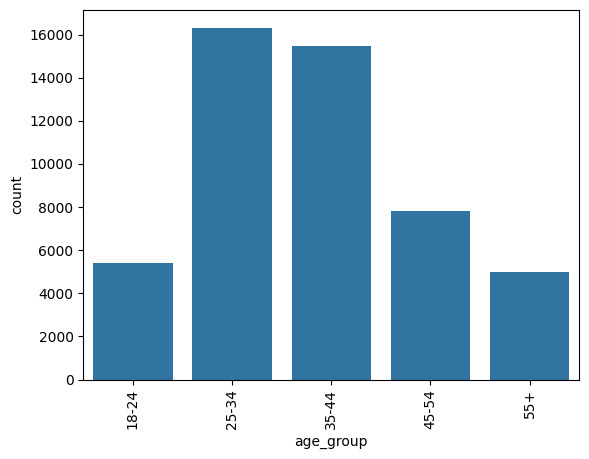

In [ ]:
# Merging Datasets
import matplotlib.pyplot as plt
import seaborn as sns
merged_df = pd.merge(hotels, reviews, on='hotel_id', how='inner')
merged_df = pd.merge(merged_df, users, on='user_id', how='inner')
#print(merged_df['country_x'].unique())
sns.countplot(data=merged_df, x='age_group')
plt.xticks(rotation=90)





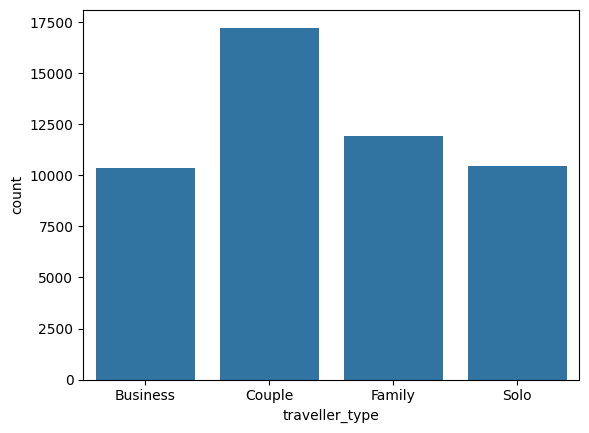

In [ ]:
sns.countplot(data=merged_df, x='traveller_type')
plt.show()

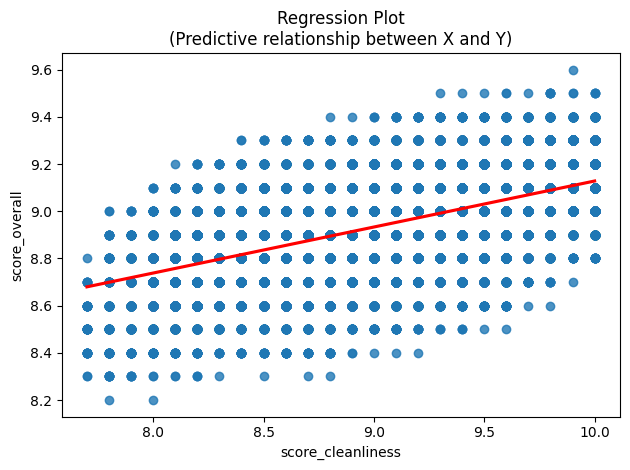

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots() # Create a figure and a single set of axes
sns.regplot(data=merged_df, y='score_overall', x='score_cleanliness',
            line_kws={"color": "red"}, ax=ax) # Pass the axes to the first regplot
ax.set_title('Regression Plot\n(Predictive relationship between X and Y)') # Set title using the created axes
plt.tight_layout()
plt.show()

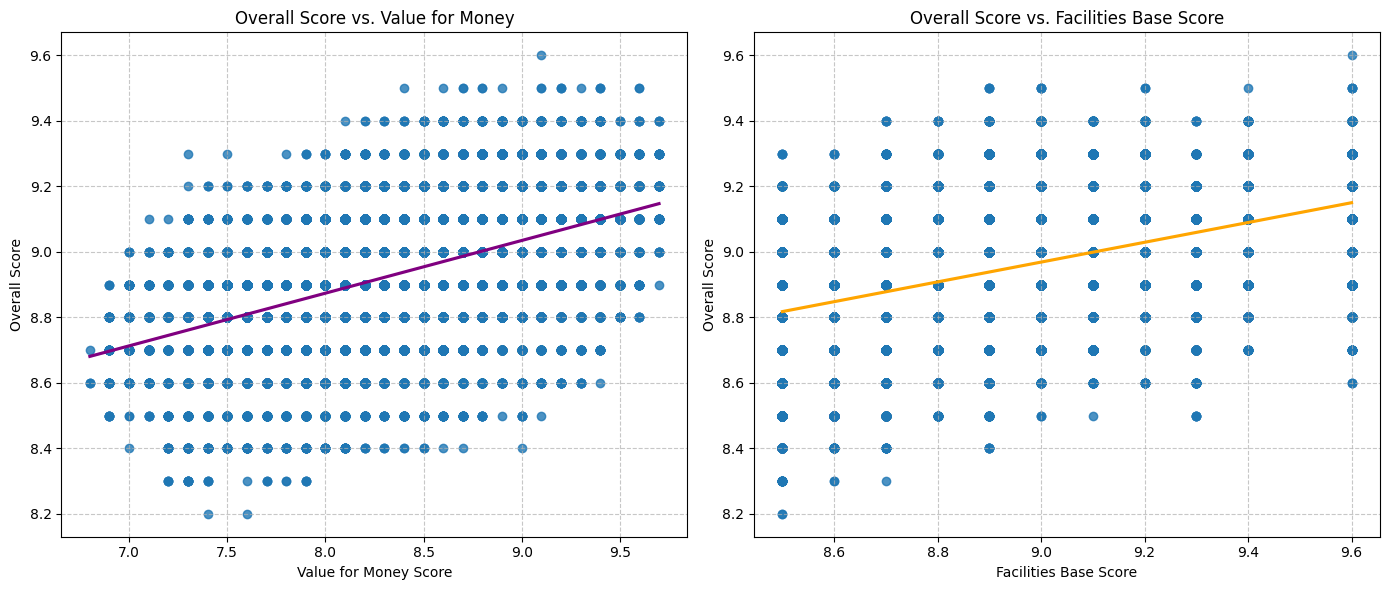

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Create 1 row, 2 columns of subplots

sns.regplot(data=merged_df, x='score_value_for_money', y='score_overall', line_kws={"color": "purple"}, ax=axes[0])
axes[0].set_title('Overall Score vs. Value for Money')
axes[0].set_xlabel('Value for Money Score')
axes[0].set_ylabel('Overall Score')
axes[0].grid(True, linestyle='--', alpha=0.7);

sns.regplot(data=merged_df, x='facilities_base', y='score_overall', line_kws={"color": "orange"}, ax=axes[1])
axes[1].set_title('Overall Score vs. Facilities Base Score')
axes[1].set_xlabel('Facilities Base Score')
axes[1].set_ylabel('Overall Score')
axes[1].grid(True, linestyle='--', alpha=0.7);

plt.tight_layout()
plt.show()

In [ ]:
print(merged_df.info())
correlation_value = merged_df['score_overall'].corr(merged_df['staff_base'])

print(f"Correlation between Column_A and Column_B: {correlation_value}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   hotel_id               50000 non-null  int64         
 1   hotel_name             50000 non-null  object        
 2   city                   50000 non-null  object        
 3   country_x              50000 non-null  object        
 4   star_rating            50000 non-null  int64         
 5   lat                    50000 non-null  float64       
 6   lon                    50000 non-null  float64       
 7   cleanliness_base       50000 non-null  float64       
 8   comfort_base           50000 non-null  float64       
 9   facilities_base        50000 non-null  float64       
 10  location_base          50000 non-null  float64       
 11  staff_base             50000 non-null  float64       
 12  value_for_money_base   50000 non-null  float64       
 13  r

Regression Plot vs Correlation matrix

[https://share.google/aimode/40rRbp4CAlqmR3ao5](https://)
https://share.google/aimode/40rRbp4CAlqmR3ao5

                       score_overall  cleanliness_base  comfort_base  \
score_overall               1.000000          0.463258      0.460677   
cleanliness_base            0.463258          1.000000      0.494788   
comfort_base                0.460677          0.494788      1.000000   
facilities_base             0.477946          0.789592      0.620770   
location_base               0.129193         -0.211923     -0.031900   
staff_base                  0.475417          0.700860      0.828298   
value_for_money_base        0.241896          0.268380      0.052494   
score_cleanliness           0.543665          0.305744      0.154043   
score_comfort               0.451928          0.189191      0.385641   
score_facilities            0.422470          0.316079      0.242921   
score_location              0.065691         -0.115304     -0.013324   
score_staff                 0.403071          0.289936      0.336936   
score_value_for_money       0.470657          0.085288      0.01

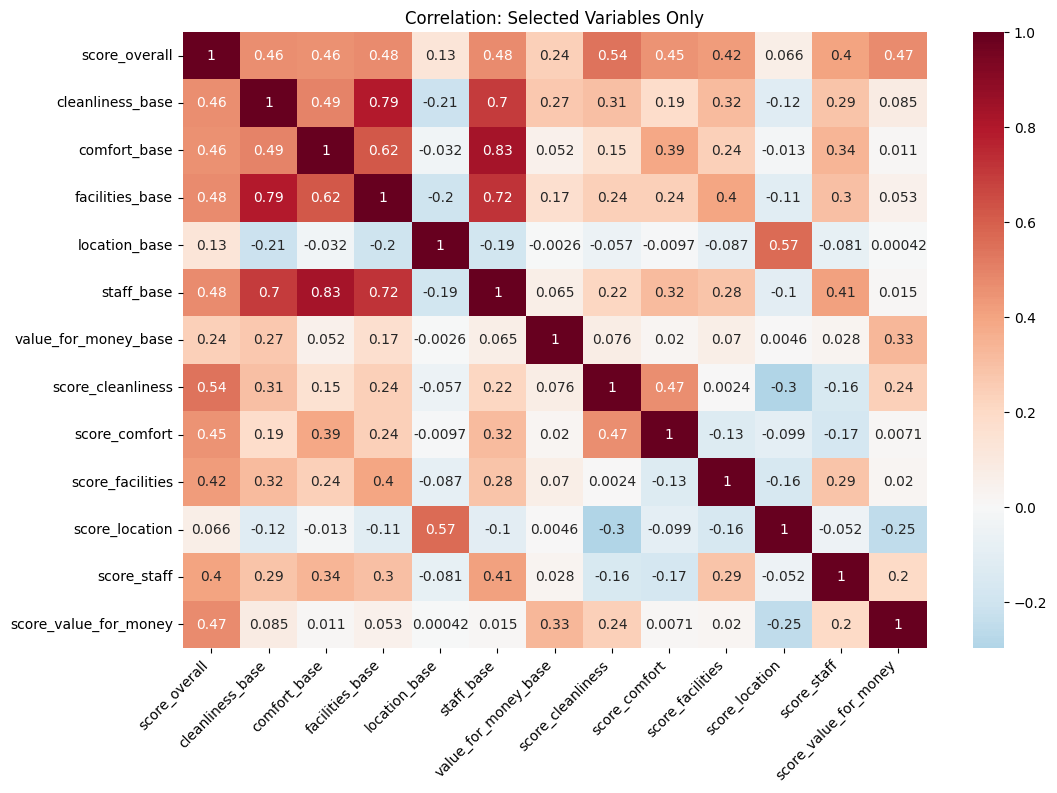

In [ ]:
selected_cols = ['score_overall','cleanliness_base', 'comfort_base', 'facilities_base',
                 'location_base','staff_base','value_for_money_base'
                ,'score_cleanliness','score_comfort',
                 'score_facilities','score_location','score_staff','score_value_for_money']

correlation_matrix = merged_df[selected_cols].corr()
fig, ax = plt.subplots(figsize=(12, 8))

print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation: Selected Variables Only")
plt.show()


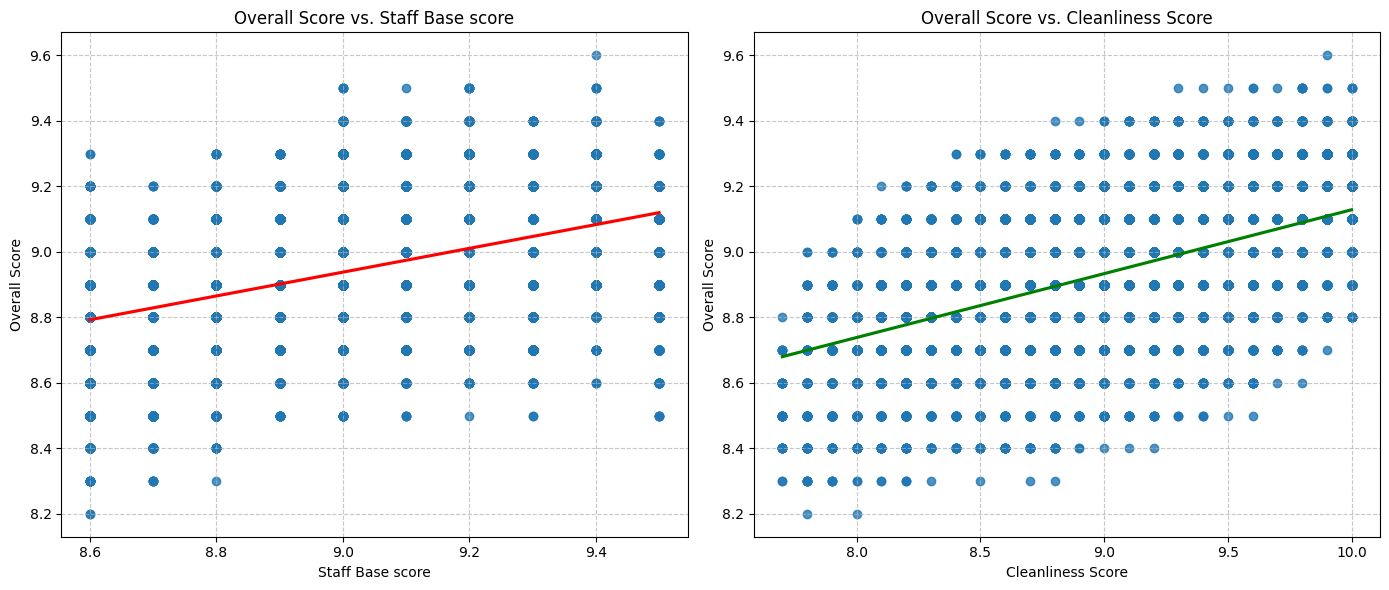

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Create 1 row, 2 columns of subplots

sns.regplot(data=merged_df, x='staff_base', y='score_overall', line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title('Overall Score vs. Staff Base score')
axes[0].set_xlabel('Staff Base score')
axes[0].set_ylabel('Overall Score')
axes[0].grid(True, linestyle='--', alpha=0.7);

sns.regplot(data=merged_df, x='score_cleanliness', y='score_overall', line_kws={"color": "green"}, ax=axes[1])
axes[1].set_title('Overall Score vs. Cleanliness Score')
axes[1].set_xlabel('Cleanliness Score')
axes[1].set_ylabel('Overall Score')
axes[1].grid(True, linestyle='--', alpha=0.7);

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Define your Target and Features
# We drop 'location' because of the low correlation we spotted
features = ['score_cleanliness', 'facilities_base', 'staff_base', 'score_value_for_money']
X = merged_df[features]
y = merged_df['score_overall']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Choose a model
# Random Forest is great here because it handles the
# remaining multicollinearity better than Linear Regression.
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 4. Check feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)


staff_base               0.391726
score_value_for_money    0.293735
score_cleanliness        0.252057
facilities_base          0.062481
dtype: float64


In [ ]:
overall_score_by_age_group = merged_df.groupby('age_group', observed=False)['score_overall'].mean()
display(overall_score_by_age_group)

,score_overall
age_group,
18-24,8.945503
25-34,8.945099
35-44,8.942732
45-54,8.943137
55+,8.938640


In [ ]:
from sklearn.metrics import r2_score

# 1. Generate predictions from your test features
y_pred = model.predict(X_test)

# 2. Calculate the R-squared score
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")


R-squared Score: 0.6145
